# 04 — Antecedente: SDCT → LDCT por conteos de fotones

## Objetivo

Conservar el modelo existente de transmisión y mostrar su diferencia con la gaussiana añadida directamente al sinograma.

**Alcance:** Antecedente experimental del desarrollo CT; su publicación en la mini-tesis ampliada no está confirmada.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Valores almacenados → min–max → Radon → I0 exp(−p/500) → Poisson o Poisson+Gaussiano → piso de 1 fotón → −log(I/I0)×500 → FBP Hann → inversa min–max. No sustituye las ramas gaussianas de los notebooks 05–09.

**Procedencia:** try_the_algorithm.ipynb; ldct/config.py, dose.py, pipeline.py, noise/* y sinogram.py; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.io import save_table
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

In [2]:
from src.noise import SimulationConfig, tube_current_time_mas, simulate_slice
from src.visualization import image_panels
from src.metrics import error_metrics
pair = prepare_pair(config)
sd, ld = pair['sdct_dcm'], pair['ldct_dcm']
mapping_sd = (float(getattr(sd, 'RescaleSlope', 1)), float(getattr(sd, 'RescaleIntercept', 0)))
mapping_ld = (float(getattr(ld, 'RescaleSlope', 1)), float(getattr(ld, 'RescaleIntercept', 0)))
if mapping_sd != mapping_ld:
    raise ValueError('El antecedente usa valores almacenados: exige mappings iguales.')
settings = SimulationConfig(**config['photon_simulation']['config'])
source_mas = tube_current_time_mas(sd)
target_mas = source_mas * config['photon_simulation']['low_dose_fraction']
results = {model: simulate_slice(sd.pixel_array, source_mas, target_mas, noise=model,
                                 config=settings, rng=config['seed']) for model in ('poisson', 'poisson_gaussian')}
result = results['poisson_gaussian']
real_low = (ld.pixel_array.astype(float) - result['normalization'].minimum) / result['normalization'].range
show_table([{'source_mAs': source_mas, 'target_mAs': target_mas, 'I0': result['incident_count'],
             'projection_scale': settings.projection_scale, 'gaussian_scale_counts': settings.gaussian_scale,
             'filter': settings.filter_name, 'circle': settings.circle, 'count_floor': settings.count_floor}])

source_mAs,target_mAs,I0,projection_scale,gaussian_scale_counts,filter,circle,count_floor
51.87,5.187,13641.8,500,0.05,hann,False,1


I0=2630×mAs objetivo procede de la calibración empírica C095 del notebook actual. El flujo alternativo histórico es I0=(0.015×mAs objetivo+0.1002)×mAs fuente×1000 y sigue disponible en src/noise.py cuando incident_photons_per_mas=None. No son calibraciones intercambiables. La gaussiana aquí tiene sigma=0.05√conteos esperados y actúa antes del logaritmo.

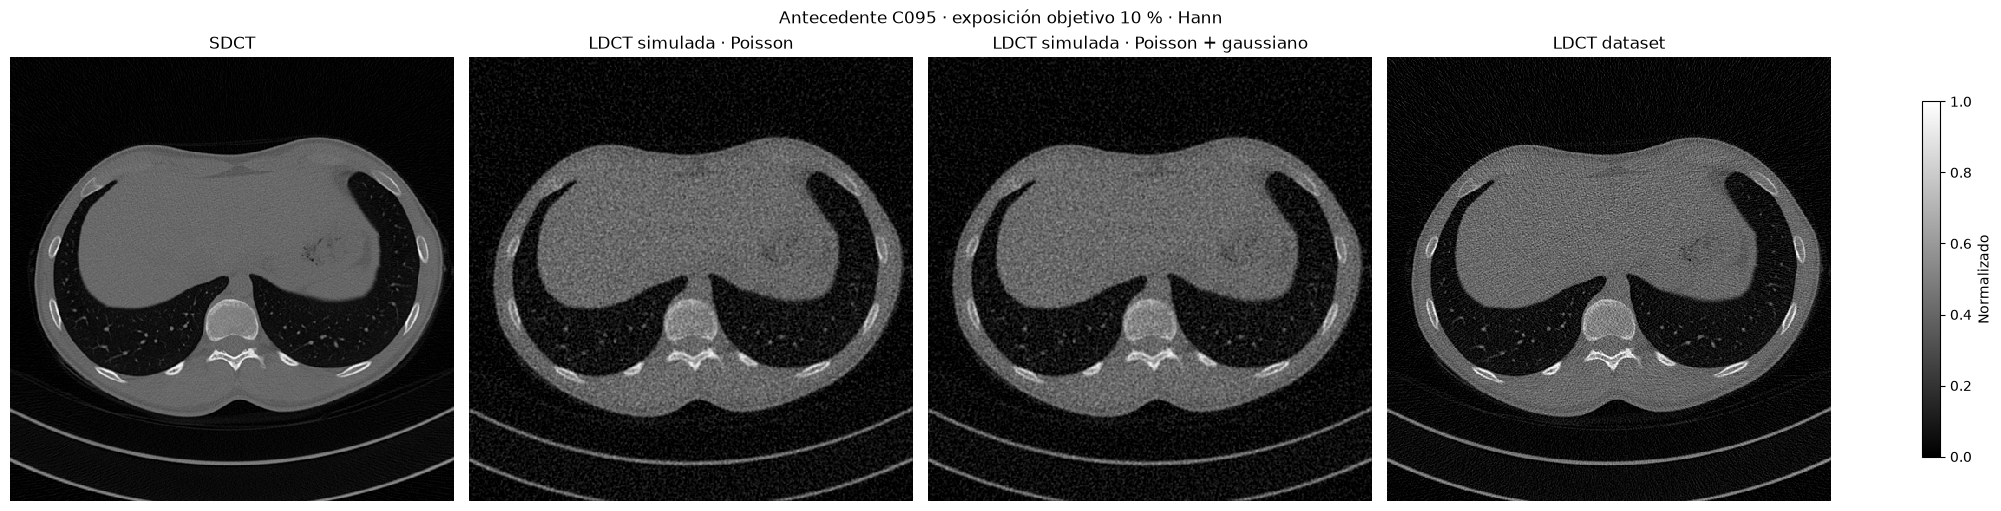

model,floored_counts,MAE,RMSE,MAX
poisson,0,0.0413785,0.0523495,0.315013
poisson_gaussian,0,0.0414232,0.0524013,0.31385
LDCT dataset,0,0.0300858,0.040773,0.248485


In [3]:
fig = image_panels([result['original_normalized'], results['poisson']['reconstruction_normalized'],
                    result['reconstruction_normalized'], real_low],
                   ['SDCT', 'LDCT simulada · Poisson', 'LDCT simulada · Poisson + gaussiano', 'LDCT dataset'],
                   title='Antecedente C095 · exposición objetivo 10 % · Hann')
finish_figure(fig, output_path('figures', '04_photons.png'))
rows = [dict(model=model, floored_counts=r['floored_counts'],
             **error_metrics(r['original_normalized'], r['reconstruction_normalized'])) for model, r in results.items()]
rows.append(dict(model='LDCT dataset', floored_counts=0, **error_metrics(result['original_normalized'], real_low)))
show_table(rows)
save_table(rows, output_path('tables', '04_photons.csv'))
np.savez_compressed(output_path('reconstructed_images', '04_photons.npz'),
                    **{model + '_sinogram': r['sinogram'] for model, r in results.items()},
                    **{model + '_reconstruction': r['reconstruction_normalized'] for model, r in results.items()})

## Observaciones

Se conserva el simulador activo, incluidas sus correcciones previamente documentadas. Los errores usan SDCT como referencia y escala normalizada, a diferencia de las métricas HU del experimento principal. El factor 500 y 2630 fotones/mAs son empíricos. No hay evidencia de que este recorrido produzca las cifras del informe de Ramp; queda como antecedente, sin incorporar los fantomas Dosis 8 ni sus ROIs.